# Introducción al Aprendizaje Máquina
## Modelos Basados en Árboles

### Notebook 3.1 — Métricas de bondad de ajuste para árboles de regresión

**Autores**

- Erick Eduardo Aguilar Hernández
- Francisca Irene Soler Anguiano

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Libro asociado**

Introducción al Aprendizaje Máquina: Modelos Basados en Árboles

**Capítulo**

Capítulo 3. Estimación del error fuera de muestra

**Licencia**

MIT License

---

Este notebook reproduce la implementación de métricas de bondad de ajuste para un árbol de regresión. 
El objetivo es distinguir entre el desempeño observado en entrenamiento y el desempeño fuera de muestra, usando una partición entrenamiento-prueba del conjunto **Auto MPG**.
___


### Preparación del entorno de trabajo

Se importan las bibliotecas necesarias para cargar datos, ajustar árboles de regresión, realizar la partición entrenamiento-prueba y calcular métricas de desempeño. 
También se fija el estilo gráfico `ggplot` y se silencian advertencias futuras para mantener una salida limpia durante la ejecución del notebook.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score as r2
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import explained_variance_score as expv
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')


### Función auxiliar para métricas de regresión

La evaluación de un modelo de regresión requiere resumir la diferencia entre los valores observados y los valores predichos. 
Esta función calcula $R^2$, MAE, MSE, RMSE y varianza explicada para un conjunto dado. 
Con ello se obtiene una tabla comparable entre entrenamiento y prueba, tal como se plantea en la sección de métricas de bondad de ajuste del libro.


In [2]:
def get_metrics(df, target_col, prediction_col, fold='Training'):
  metrics_dict = {'fold':fold}
  metrics_dict.update({'R2':r2(df[target_col],df[prediction_col])})
  metrics_dict.update({'MAE':mae(df[target_col],df[prediction_col])})
  metrics_dict.update({'MSE':mse(df[target_col],df[prediction_col])})
  metrics_dict.update({'RMSE':np.sqrt(mse(df[target_col],df[prediction_col]))})
  metrics_dict.update({'ExpVar':expv(df[target_col],df[prediction_col])})
  return metrics_dict


### Carga del conjunto Auto MPG

Se carga el conjunto **Auto MPG**, donde la variable objetivo `mpg` representa el rendimiento de combustible del vehículo. 
Las variables predictoras seleccionadas corresponden a características técnicas del automóvil. 
Después de eliminar observaciones incompletas, se construyen la matriz de predictores `X` y el vector respuesta `y`.


In [3]:
data_paths = [Path("datos") / "mpg.csv", Path("..") / "datos" / "mpg.csv"]
data_path = next(path for path in data_paths if path.exists())
mpg_df = pd.read_csv(data_path).dropna()

features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

X = mpg_df[features]
y = mpg_df["mpg"]

display(mpg_df)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


### Partición entrenamiento-prueba

Para estimar el error fuera de muestra, el conjunto de datos se divide aleatoriamente en dos subconjuntos disjuntos. 
El conjunto de entrenamiento se utiliza para ajustar el árbol y el conjunto de prueba se reserva para evaluar predicciones sobre observaciones que no participaron en el ajuste. 
Se usa `test_size = 0.2` para reservar el 20 % de los datos y `random_state = 42` para que la partición sea replicable.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Observaciones de entrenamiento: {X_train.shape[0]}")
print(f"Observaciones de prueba: {X_test.shape[0]}")


Observaciones de entrenamiento: 313
Observaciones de prueba: 79


### Ajuste del árbol y generación de predicciones

El árbol de regresión se ajusta únicamente con las observaciones del conjunto de entrenamiento. 
Se controla su complejidad mediante `max_depth = 4` y `min_samples_leaf = 10`, los mismos criterios de pre-poda usados en el capítulo anterior. 
Después del ajuste, se generan predicciones tanto para entrenamiento como para prueba, lo que permitirá comparar el error dentro y fuera de muestra.


In [5]:
tree_regressor = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

tree_regressor.fit(X_train, y_train)
train_pred = tree_regressor.predict(X_train)
test_pred = tree_regressor.predict(X_test)


### Construcción de tablas de evaluación

Para calcular las métricas se construyen dos tablas auxiliares: una para entrenamiento y otra para prueba. 
Cada tabla conserva las covariables originales e incorpora `y_true`, con el valor observado, y `y_pred`, con la predicción del árbol. 
Esta organización permite aplicar la misma función de evaluación a ambos subconjuntos.


In [6]:
train_eval_df = X_train.copy()
train_eval_df["y_true"] = y_train.values
train_eval_df["y_pred"] = train_pred

test_eval_df = X_test.copy()
test_eval_df["y_true"] = y_test.values
test_eval_df["y_pred"] = test_pred


### Comparación del desempeño en entrenamiento y prueba

Finalmente se calculan las métricas para ambos subconjuntos y se presentan en una misma tabla. 
El error de entrenamiento mide qué tan bien el modelo reproduce los datos usados para ajustarlo, mientras que el error de prueba aproxima su desempeño sobre datos no observados durante el entrenamiento. 
Una diferencia moderada entre ambos resultados sugiere buen control de la varianza; una brecha grande puede indicar sobreajuste.


In [7]:
train_metrics = get_metrics(
    train_eval_df,
    target_col="y_true",
    prediction_col="y_pred",
    fold="Training"
)

test_metrics = get_metrics(
    test_eval_df,
    target_col="y_true",
    prediction_col="y_pred",
    fold="Test"
)

results = pd.DataFrame([train_metrics, test_metrics])
display(results)


,fold,R2,MAE,MSE,RMSE,ExpVar
0,Training,0.882852,1.996784,7.392024,2.718828,0.882852
1,Test,0.819163,2.328065,9.230015,3.038094,0.819163


### Comparación visual de métricas

Para complementar la tabla anterior, se construye una gráfica de barras que compara las métricas obtenidas en entrenamiento y prueba. 
La tabla de resultados se transforma a formato largo para representar cada métrica en el eje horizontal y usar el conjunto evaluado (`Training` o `Test`) como variable de color mediante `hue`. 
Esta visualización facilita observar si el desempeño fuera de muestra se deteriora de manera importante respecto al ajuste en entrenamiento.


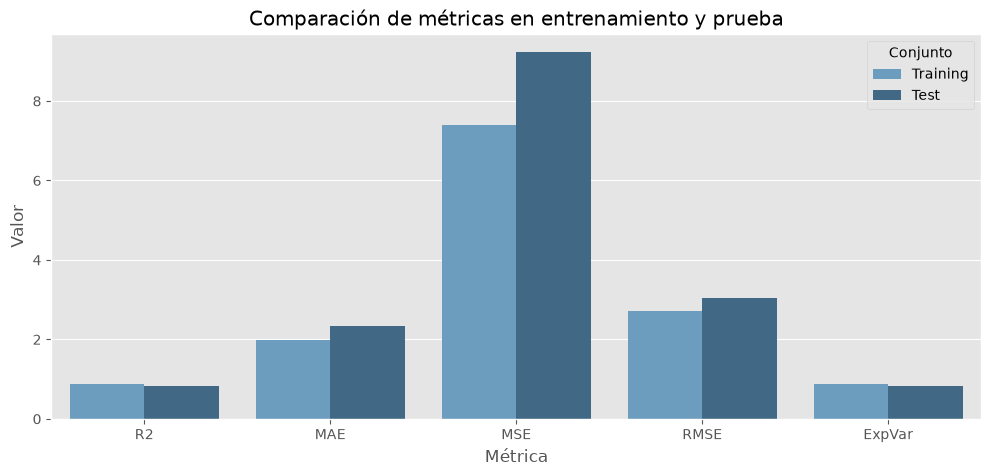

In [10]:
metrics_long_df = results.melt(
    id_vars="fold",
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=metrics_long_df,
    x="metric",
    y="value",
    hue="fold",
    palette="Blues_d"
)
plt.title("Comparación de métricas en entrenamiento y prueba")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.legend(title="Conjunto")
plt.show()
